# Manipulação de arquivos

In [ ]:
# Gerar um caminho

import os.path # os = operational system
caminho = os.path.join('C', 'Chico', 'Dados', 'todo_list.txt')
print (caminho)

C/Chico/Dados/todo_list.txt


# Ler arquivos
Método read

In [ ]:
# Abrir o arquivo
iris = open('/content/iris.csv','r')
iris

In [ ]:
# Exibir o conteúdo do arquivo
iris.readlines()

In [ ]:
# Fechar o arquivo
iris.close()

Método write

In [ ]:
# Abrir um arquivo e, simultaneamente, deixá-lo apto a ser escrito.
arquivo = open('/content/iris.csv','r+')

In [ ]:
arquivo.close()

Criar um arquivo novo e escrever nele

In [ ]:
arquivo = open('/content/arquivo.txt','w')

In [ ]:
arquivo.write('A, B, C, D, E')

Agora execute novamente a célula acima e inspecione o arquivo novamente. O que aconteceu?

Após executar a célula acima pelo menos duas vezes, execute a célula abaixo. O que aconteceu?

In [ ]:
arquivo.tell()

In [ ]:
arquivo.close()

Clique duas vezes no arquivo.txt, em Files, para inspecionar o conteúdo.

# Agora um exemplo geológico real

Criar e escrever arquivos .csv

In [ ]:
gama = open('/content/gama.txt','w')

In [ ]:
lista_cabecalho = ['CT\t', 'K\t', 'Th\t', 'U\t\n']
gama.writelines(lista_cabecalho)

In [ ]:
lista_medidas = [34.0, 2.0, 7.0, 1.7]
gama.writelines(lista_medidas)

In [ ]:
# Passando a lista com os valores no formato string
lista_medidas = ['34.0', '2.0', '7.0', '1.7']
gama.writelines(lista_medidas)

In [ ]:
# Passando a lista com os valores no formato string e adicionando tabulação
lista_medidas = ['34.0\t', '2.0\t', '7.0\t', '1.7\t']
gama.writelines(lista_medidas)

In [ ]:
gama.close()

Fazendo leituras sequenciais e criando uma base de dados

In [ ]:
gama3 = open('/content/gama3 .txt','w')
lista_cabecalho = ['CT\t', 'K\t', 'Th\t', 'U\t\n']
gama3.writelines(lista_cabecalho)

In [ ]:
# Passando várias listas
lista_pto_01 = ['34.5\t', '2.1\t', '6.9\t', '1.9\t\n']
gama3.writelines(lista_pto_01)
lista_pto_02 = ['34.2\t', '2.7\t', '7.3\t', '1.5\t\n']
gama3.writelines(lista_pto_02)
lista_pto_03 = ['34.9\t', '2.9\t', '7.4\t', '1.6\t\n']
gama3.writelines(lista_pto_02)
lista_pto_04 = ['34.7\t', '2.3\t', '7.7\t', '1.2\t\n']
gama3.writelines(lista_pto_02)
lista_pto_05 = ['34.2\t', '2.2\t', '7.0\t', '1.0\t\n']
gama3.writelines(lista_pto_02)

In [ ]:
gama3.close()

Criar uma base de dados usando laço de repetição

In [ ]:
unidade_lito = ['Fm. A', 'Fm. A','Fm. A','Fm. A','Fm. A','Fm. B','Fm. B','Fm. B','Fm. B','Fm. B']
contagem_total = [34, 32, 36, 34, 35, 39, 40, 41, 44, 45]
potassio = [2.0, 2.1, 2.4, 2.5, 2.7, 2.8, 2.8, 3.0, 3.4, 3.1]
torio = [ 7.0, 7.7, 6.5, 8.6, 8.1, 10.3, 12.0, 11.0, 13.0, 12.8]
uranio = [ 1.7, 2.7, 2.5, 3.6, 3.1, 4.3, 4.0, 4.1, 3.8, 4.3]

# Função zip para concatenar
for unidade, CT, K, Th, U in zip(unidade_lito, contagem_total, potassio, torio, uranio):
  print (unidade, CT, K, Th, U)

# Montar um drive no Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Importar a biblioteca Pandas

In [ ]:
import pandas as pd

In [ ]:
# Construir o dataframe

df = pd.read_csv('/content/drive/ ????? /NA_12_RJS_original.csv')

''' Leia e entenda a mensagem de erro. Em seguida, vá adiante '''

ParserError: ignored

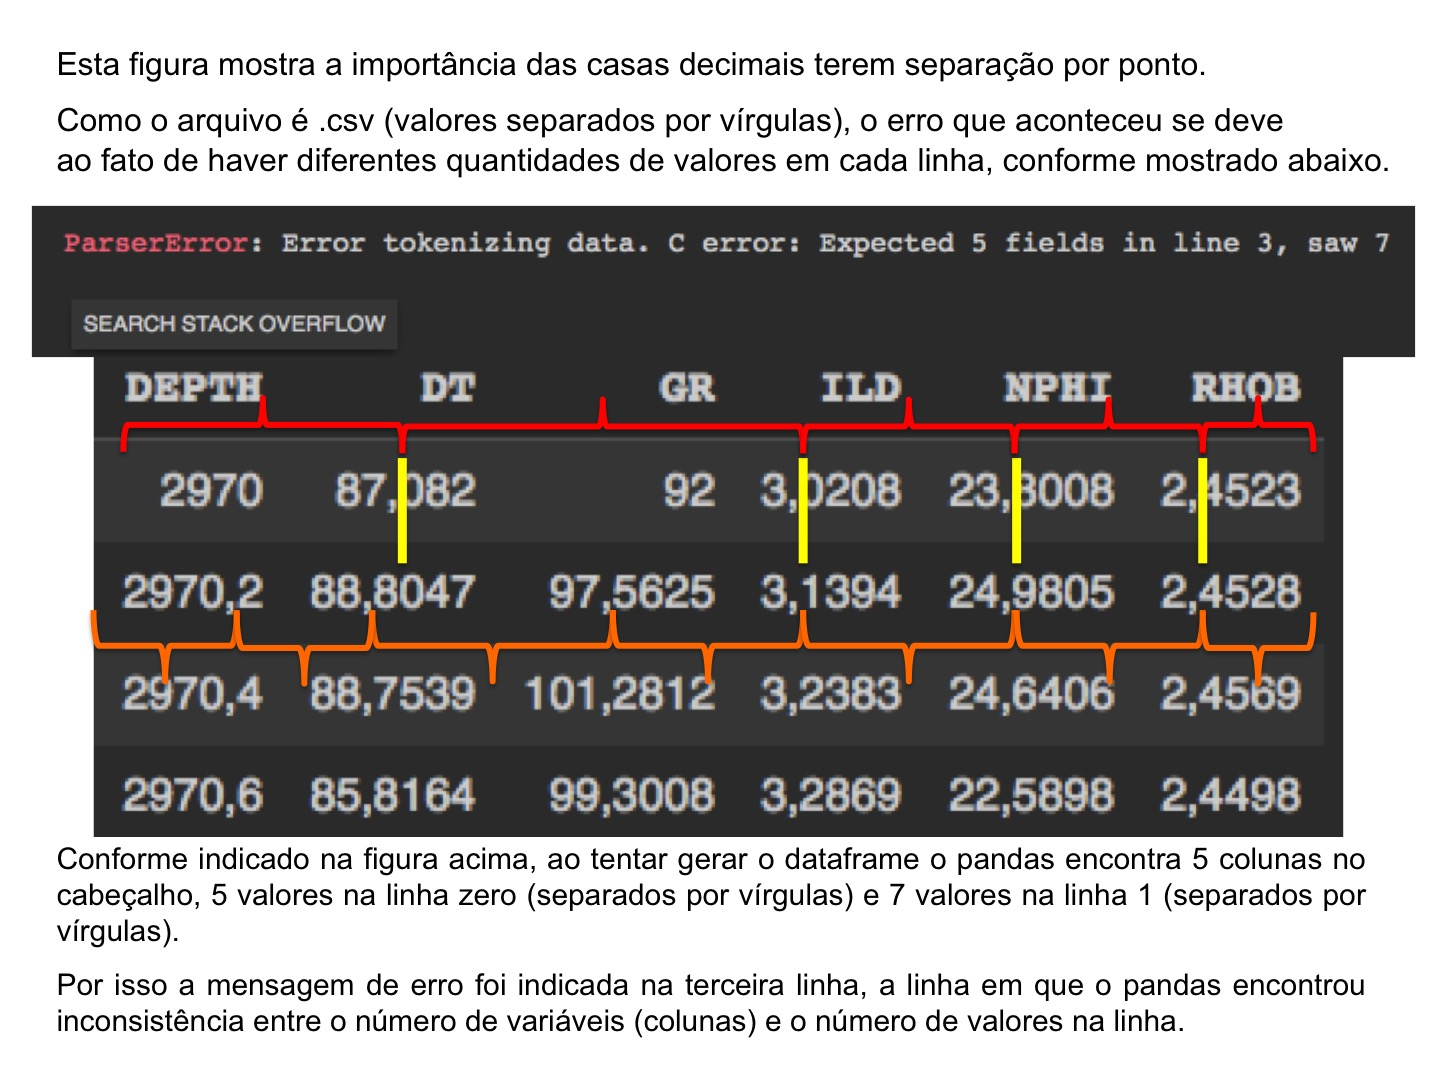

In [ ]:
# Tentemos novamente informando na linha de código qual separador deve ser usado.

df = pd.read_csv('/content/drive/MyDrive/ ???????? /NA_12_RJS_original.csv', sep= 'delimiter')
df

# Ao inserir delimiter como separador, o pandas insere um ; nos espaços entre os números.
# Isso faz com que o dataframe possa ser gerado, mas os números ficam todos "zoados".

Para resolver este problema, devemos:

1) Substituir todas as vírgulas por pontos. Apenas isto possivelmente resolverá o problema.

2) Definir o separador na linha de código, como abaixo.

3) Convém também neste momento já indicar qual linha contém o cabeçalho (no caso, a linha 0).



In [ ]:
# Tentemos novamente, agora indicando a separação decimal, o separador e a linha do cabeçalho.

df = pd.read_csv('/content/drive/MyDrive/ ?????? /NA_12_RJS_original.csv', decimal = ',', sep= ';', header=0)
df

Variáveis numéricas que não referem-se a propriedades medidas podem também ser convertidas para um formato que impeça sua utilização para análises numéricas diversas (ex: não faz sentido calcular a profundidade média do poço NA_12-RJS).


Para isso, adicionamos a instrução dtype para especificar o tipo de dado desejado.

In [ ]:
# Tentemos novamente, agora redefinindo a coluna DEPTH como objeto, e não mais como float.
df1 = pd.read_csv('/content/drive/MyDrive/  ???   /NA_12_RJS_original.csv',
                  decimal = ',', sep= ';', header=0, dtype = {'DEPTH': 'object'})
df1

Note que após a conversão da coluna DEPTH de float para object, o separador decimal voltou a ser , . Isto aconteceu porque um object não entende a instrução de decimal por ponto passada na linha de código. O decimal por ponto só faz sentido para float.

In [ ]:
# Com o dataframe correto, você pode exportar uma versão do arquivo com os separadores decimais definidos para . (ponto)
# CUIDADO, toda vez que você executar esta célula, o arquivo será sobrescrito na pasta do Google Drive ou na raiz.
# Uma maneira de evitar executar o código por acidente é colocando # na frente.
'''Outra maneira é inserir 3 aspas antes e depois da linha de código'''

# Note que exportaremos o .csv do df. O df1 foi gerado apenas para ilustrar a conversão de float para object.
df.to_csv('/content/drive/MyDrive/   ???   /NA_12_RJS_pontos.csv')

# VAMOS ADIANTE

Agora que estamos com a base de dados carregada e disponível como um dataframe padronizado, realizaremos uma série de verificações para conhecermos o dado (Data Inspection).

Essa etapa é muitas vezes neglicenciada pelo usuário/intérprete.

A **qualidade do dado** é fundamental para os resultados obtidos a partir deles.




LEMBRE-SE:

A linguagem de programação é uma ferramenta que te ajuda a executar tarefas.
O intérprete é responsável por inspecionar e proceder para que a base de dados tenha a qualidade necessária para o projeto em execução.

DITO DE OUTRA FORMA:

"**Algoritmos e linguagem de programação não fazem milagres se o seu dado for ruim**"

# VERIFICAÇÃO DE DADOS (OU *DATA INSPECTION*)

Os códigos executados a seguir nos auxiliarão a conhecer e editar nossa base de dados (dataset) convertida em um dataframe.



In [ ]:
# Imprimir o tipo de dataset.



In [ ]:
# Essa função lista o tipo de dataset, todas as variáveis, informa o número de valores (entries) em cada coluna e o tipo de dado.
# Além disso, informa na última linha o uso de memória. 48 KB é um arquivo muito pequeno.



Notem que o primeiro dataframe gerado (df) não utilizou a instrução dtype. Por isso, os valores de profundidade são entendidos como números do tipo float.

o df1 foi criado com a conversão da variável profundidade para object (ou seja, uma string). Assim, apesar do valor numérico aparecer normalmente na visualização do dataframe, ele não está em um formato que pode ser utilizado para cálculos. Por exemplo, não será possível calcular o valor médio das profundidades.

Esta conversão pode ser bastante útil para variáveis numéricas que não tenham importância ou relação com propriedades da rocha, ou que não seja conveniente ficar disponível para serem usadas por algoritmos.

In [ ]:
df1.info()

Seguiremos trabalhando com o df

In [ ]:
# Instrução columns para visualizar todas as colunas em formato de lista


In [ ]:
# Instrução para saber qual o número de linhas (1025) e de colunas (6) do dataframe, em formato de tupla


In [ ]:
# Instrução determinar quantidade de linhas com valores não-nulos, para cada variável.


In [ ]:
# Imprimir as 5 primeiras linhas do dataframe usando a instrução head()



In [ ]:
# indicar número desejado dentro dos () até o limite de 60.


In [ ]:
# Imprimir as 5 últimas linhas do dataframe
# Assim como o .head(), pode-se inserir o número de linhas que deseja ver no final do dataframe dentro dos ().


In [ ]:
# Exibir uma amostra aleatória do dataframe
# Cada vez que se executar a célula, uma linha diferente será mostrada


# DESAFIO
QUAIS OS VALORES DA MÉDIA, VALOR MÍNIMO, VALOR MÁXIMO E DESVIO-PADRÃO DA VARIÁVEL ILD?

SERÁ CONTADO O TEMPO ATÉ A CONCLUSÃO DA TAREFA.

In [ ]:
# Estatística descritiva


In [ ]:
# Neste momento, percebemos que é melhor que a variável profundidade seja do tipo object.
# Lembre-se que anteriormente convertemos a coluna DEPTH de float para object usando o dtype.
# Ao invés de carregar novamente o dataframe e repetir todas as execuções de células, faça assim:

'''df.DEPTH = df.DEPTH.astype('object')''''

# Retire as aspas antes de executar a linha de código acima, caso seja necessário converter alguma coluna.

In [ ]:
# Para checar se a conversão de fato ocorreu:

'''df.info()'''

Suponhamos que a partir de agora precisemos utilizar apenas algumas poucas variáveis. A instrução usecols permite escolher as variáveis a partir de sua posição no dataframe.

Com isso, se quisermos eliminar as curvas ILD e DT do df, não podemos incluir as colunas que estão na posição 1 (DT) e 3 (ILD). Veja acima, em df.info() a posição das colunas no dataframe.

In [ ]:
df_teste = pd.read_csv('/content/drive/MyDrive/  ??  /NA_12_RJS_original.csv', decimal = ',', sep= ';', header=0,
                       usecols=[0,1,2,3,4,5])
df_teste.head()

Datasets com uma quantidade grande de colunas pode tornar esta tarefa demorada e sujeita a erros. Outra maneira de usar o usecols é passando uma lista com os nomes da variáveis desejadas, como mostrado abaixo.

In [ ]:
df_teste = pd.read_csv('/content/drive/MyDrive/  ??   /NA_12_RJS_original.csv', decimal = ',', sep= ';', header=0,
                       usecols=['DEPTH','DT', 'GR','ILD','NPHI','RHOB'])
df_teste.head()

In [ ]:
df_teste.drop(['ILD', 'DT'], axis=1, inplace=True)
df_teste

LEMBRETE

É possível obter todas as colunas do dataframe em formato de lista usando a instrução df.columns, no caso, df_teste.columns

Basta selecionar, copiar e colar no usecols.

In [ ]:
df.columns

Se o dataframe tiver muitas colunas, o arquivo for muito grande e o número de colunas necessárias para o projeto for pequeno, restringir o dataframe ao número de colunas essenciais reduzirá drasticamente o uso de memória.

Terminado o teste acima, voltemos à Verificação de Dados com base no df. Como ele não foi sobrescrito durante o teste anterior (utilizamos o df_teste), então basta chamá-lo na linha de código.

# Consultas no dataframe

In [ ]:
# Calcular a média de todas as variáveis numéricas

            # troque mean por std (desvio-padrão), skew (assimetria), kurtosis (curtose), min (mínimo) ou max (máximo)

In [ ]:
# Calcular a média dos valores de apenas uma variável

            # da mesma forma, você pode trocar mean por outros parâmetros estatísticos

67.81139307317073

In [ ]:
# Contar quantidade de valores únicos - ex: quantas vezes um valor se repete

pd.value_counts(df['DT'])

In [ ]:
# Instrução loc() para visualizar informações do dataframe
# Recebe lista (observe os [ ]) por parâmetro e retorna resultado da consulta

df.loc[df['ILD']>=50.0]

In [ ]:
# Como determinar a quantidade de linhas que atendem a condição passada

df.loc[df['ILD']>=50.0].count()

É possível localizar amostras com base em duas condições simultâneas?

SIM. Basta usar o operador &

In [ ]:
df.loc[(df['ILD']>=100.00) & (df['GR']<60.0)]

In [ ]:
# Encontrar os n maiores valores de uma variável

df[['DEPTH','ILD']].nlargest(5,'ILD')

In [ ]:
# Encontrar os n menores valores de uma variável

df[['DEPTH','ILD']].nsmallest(5,'ILD')

In [ ]:
# Instrução sort_values() para ordenar pela coluna escolhida, em decrescente
# Para ordenar de forma crescente, use ascending=True

df.sort_values(by='NPHI', ascending=False)

# Método Iterrows

Como usar um laço de repetição durante a execução de um projeto prático

In [ ]:
# Percorrer o df e imprimir o índice e cada linha usando o método iterrows

for variavel, valor in df.head(3).iterrows():  # o (3) refere-se ao número de linhas a ser mostrado
    print(variavel, valor)

0 DEPTH    2970.0000
DT         87.0820
GR         92.0000
ILD         3.0208
NPHI       23.8008
RHOB        2.4523
Name: 0, dtype: float64
1 DEPTH    2970.2000
DT         88.8047
GR         97.5625
ILD         3.1394
NPHI       24.9805
RHOB        2.4528
Name: 1, dtype: float64
2 DEPTH    2970.4000
DT         88.7539
GR        101.2812
ILD         3.2383
NPHI       24.6406
RHOB        2.4569
Name: 2, dtype: float64


# Método Itertuples

In [ ]:
# Método itertuples retorna linhas e índice em formato de tuplas
# Costuma ser mais rápido que o iterrows()

for variavel in df.head(12).itertuples():
    print(variavel)

Pandas(Index=0, DEPTH=2970.0, DT=87.082, GR=92.0, ILD=3.0208, NPHI=23.8008, RHOB=2.4523)
Pandas(Index=1, DEPTH=2970.2, DT=88.8047, GR=97.5625, ILD=3.1394, NPHI=24.9805, RHOB=2.4528)
Pandas(Index=2, DEPTH=2970.4, DT=88.7539, GR=101.2812, ILD=3.2383, NPHI=24.6406, RHOB=2.4569)
Pandas(Index=3, DEPTH=2970.6, DT=85.8164, GR=99.3008, ILD=3.2869, NPHI=22.5898, RHOB=2.4498)
Pandas(Index=4, DEPTH=2970.8, DT=82.9414, GR=96.8398, ILD=3.334, NPHI=19.9883, RHOB=2.45)
Pandas(Index=5, DEPTH=2971.0, DT=82.4453, GR=93.7031, ILD=3.446, NPHI=19.4922, RHOB=2.4587)
Pandas(Index=6, DEPTH=2971.2, DT=83.3984, GR=87.625, ILD=3.6001, NPHI=21.6797, RHOB=2.4671)
Pandas(Index=7, DEPTH=2971.4, DT=84.3438, GR=82.8438, ILD=3.6523, NPHI=22.332, RHOB=2.481)
Pandas(Index=8, DEPTH=2971.6, DT=84.9648, GR=83.7656, ILD=3.5767, NPHI=21.4023, RHOB=2.4885)
Pandas(Index=9, DEPTH=2971.8, DT=86.4922, GR=87.9883, ILD=3.4561, NPHI=21.4531, RHOB=2.4773)
Pandas(Index=10, DEPTH=2972.0, DT=89.0078, GR=89.2952, ILD=3.3838, NPHI=21.6758,

In [ ]:
# Para executar o bloco de códigos a seguir, precisaremos importar a biblioteca numpy
import numpy as np

# usando um laço de repetição para determinar o formato de saída do output
for i, column in enumerate(df.select_dtypes(include=np.number).columns.tolist()):
    mean = round(df[column].mean(),2)
    std = round(df[column].std(),2)
    median = round(df[column].median(),2)
    cvar = round(std/mean*100,2)
    print('Atributo: {}, Média: {}, Mediana: {}, Coeficiente de Variação: {}%'.format(column, mean, median, cvar,))

# VALORES FALTANTES (NULL)

Valores podem estar ausentes em razão de falhas no registro, falhas de carregamento, falhas em web crawlers e arquivos corrompidos.

Algoritmos de Machine Learning não trabalham com valores faltantes.

In [ ]:
# Uma forma (pouco prática) de verificar se há valores faltantes no dataframe

df.isnull()

In [ ]:
# Outra forma (muito mais prática) de consultar linhas com valores faltantes em cada coluna

df.isnull().sum()

In [ ]:
# Determinar o total de valores faltantes em todo o dataframe

df.isnull().sum().sum()

In [ ]:
# Pode-se determinar também a quantidade de valores não faltantes

df.notnull().sum().sum()

# O que fazer com valores faltantes no dataframe?

That's the question



# É interessante jogar dados fora?

Vamos utilizar o arquivo do NA-12-RJS que teve alguns valores removidos intencionalmente para você fazer o exercício.

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/  ??   /NA_12_RJS_editado.csv', decimal = ',', sep= ';', header=0)
df1

In [ ]:
# Qual outra opção, para não ter que copiar a célula do pd.read novamente, ou ter que buscar o arquivo na pasta do drive?

'''df1 = df'''

In [ ]:
df1.isnull().sum()

In [ ]:
df1.isnull().sum().sum()

Opção 1: remover

ALERTA:

Ao executar a célula abaixo, o dataframe deixará de ter células vazias.

Por este motivo, utilizaremos o artifício de criar diferentes dataframes, iguais ao df1 que estamos trabalhando mas com um nome diferente. Assim você poderá avaliar os diferentes resultados que serão gerados.

In [ ]:
# Se sua decisão for remover os valores faltantes, utilize a instrução dropna
# Ela remove as linhas que tenham pelo menos um valor faltante em alguma coluna.

# (inplace=True) para alterar o dataframe em memória.
# Ou seja, o df será atualizado com a exclusão das linhas que contém valores faltantes.

df2 = df1
df2.dropna(inplace=True)
df2

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/  ???  /NA_12_RJS_editado.csv', decimal = ',', sep= ';', header=0)


In [ ]:
# Para remover somente linhas que tenham valores faltantes em todas as colunas

df3 = df1   # criando uma variável para guardar um dataframe inteiro
df3.dropna(how='all', inplace=True)
df3

Opção 2: preencher as células vazias

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/  ??   /NA_12_RJS_editado.csv', decimal = ',', sep= ';', header=0)

In [ ]:
# Para preencher com valor constante y (ex. y = 22.0) os valores ausentes (NaN) de uma coluna específica (coluna X)
# df['X'].fillna(y, inplace=True)

df4 = df1
df4['NPHI'].fillna(22.0, inplace=True)
df4['DT'].fillna(81.5, inplace=True)
df4['RHOB'].fillna(2.38, inplace=True)
df4

In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/@@Python_UNESP/NA_12_RJS_editado.csv', decimal = ',', sep= ';', header=0)

In [ ]:
# Para preeencher com a média dos valores da coluna X os valores ausentes (NaN) desta mesma coluna.

df5 = df1
df5['NPHI'].fillna(df5['NPHI'].mean(), inplace=True)
df5['DT'].fillna(df5['DT'].mean(), inplace=True)
df5['RHOB'].fillna(df5['RHOB'].mean(), inplace=True)
df5

# Operações com o dataframe

Você pode seguir utilizando o dataframe original (df) ou o dataframe com as células de valores faltantes preenchidas (df1).

Seguir utilizando o df nos auxiliará na sequência da aula, para efeito comparativo dos resultados.

In [ ]:
#df1 = pd.read_csv('/content/drive/MyDrive/   ??   /NA_12_RJS_original.csv', decimal = ',', sep= ';', header=0)
df

In [ ]:
# Consultar colunas
df.head()

# Remover linha(s) do dataframe com base em condição lógica



In [ ]:
# Apagar (dropar) linhas com DT < 40 (p.ex, valores impossíveis, erros de medição, de lab, outliers etc)
# index tem função de remeter ao índice(endereço) das linhas com o valor especificado.
df.drop(df[df.DT < 40.0].index, inplace=True)

In [ ]:
df.shape

# Adicionar coluna ao dataframe

Vamos criar e adicionar uma coluna nova no  dataframe

A nova variável é o valor de porosidade calculada a partir do perfil sônico (DT).

A fórmula é: Porosidade_DT = (Valor lido - Valor formação) / (Valor fluido - Valor formação)

In [ ]:
# Adicionar coluna ao df usando uma fórmula
# Valor lido é o valor de DT em cada linha
# Valor da formação = 56 ms/ft e valor do fluido = 189 ms/ft

df['Porosidade_DT']=((df['DT'] - 56)/133)   # Porosidade_DT é a coluna que será criada
df.head()

In [ ]:
# Estatística descritiva da coluna Porosidade_DT

df.Porosidade_DT.describe()

In [ ]:
# Adicionar coluna ao dataframe com operação entre duas colunas

df['NPHI/RHOB']=(df['NPHI']/ df['RHOB'])
df.head()

E como usar uma função para nos ajudar no projeto?

In [ ]:
# Criar função para classificar os dados da nova coluna criada

def categorias(poro_dt):
    if poro_dt >= 0.30:
        return 'Muito alta'
    elif poro_dt >= 0.15:
        return 'Alta'
    elif poro_dt >= 0.05:
        return 'Intermediária'
    else:
        return 'Muito baixa'

As categorias devem ser criadas com base em algum critério.

Se o critério for estatístico, você pode recorrer ao df.describe() para acessar os valores de média, desvio-padrão e dos quartis.

Se o critério for geológico, ou um critério definido por uma Comissão Internacional da área de pesquisa, basta consultar e utilizar os valores.

In [ ]:
# Criar coluna nova com as classes de porosidade criadas a partir da função

df['Classe_poro_dt'] = df['Porosidade_DT'].apply(categorias)
df

# Coeficiente de Pearson

Coeficiente de Pearson mede a correlação entre variáveis

Coeficiente de determinação (Rˆ2) = Pearsonˆ2

Rˆ2 = 1 - (var residual/var total) = 1 - ((valor pred - valor real)^2 / valor pred - valor med)^2)

In [ ]:
# Quando o corr() está vazio, o Python entende que deve rodar o coeficiente default (Pearson).
# Para usar outro tipo de coeficiente, adicionar o nome no parênteses. Ex: corr('kendall') ou corr ('spearman')

df.corr()

Sobre o alerta (Warning) mostrado acima, você deve sempre consultar a documentação associada à instrução, no caso corr().

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html

# Remover colunas indesejadas do df

Geramos a coluna NPHI/RHOB e, depois de inspecioná-la, decidimos que ela não será útil ao propósito do projeto em execução. Como tirá-la?

In [ ]:
df.columns

In [ ]:
# Instrução drop para excluir dados do df
# Opção axis=1 define que se quer excluir coluna.
# O parâmetro inplace define que a alteração será na memória.

df.drop(['ILD', 'DT'], axis=1, inplace=True)
df

In [ ]:
# Para checar se a remoção ocorreu:

df.columns

In [ ]:
# Ver a distribuição da coluna com o método value_counts()
pd.value_counts(df['Classe_poro_dt'])

In [ ]:
# Para salvar o dataframe com as novas colunas geradas

'''df.to_csv('//content/drive/MyDrive/ ??? /NA_12_RJS_completo.csv')'''

**Utilizaremos este último arquivo para a próxima aula, sobre Visualização de Dados.**


Mas antes disso, finalizaremos esta aula mostrando como gerar um Relatório Pandas.

Imagine que teu orientador ou gerente peça para você fazer um relatório sobre os dados de perfilagem do poço NA-12-RJS. Como você faria e quanto tempo você gastaria para elaborar um relatório envolvendo tudo que vocês fizeram na aula de hoje?

# RELATÓRIO PANDAS

# Se nenhum dos códigos abaixo funcionar, você poderá ligar a IA e pedir um código para gerar o Relatório Pandas

In [ ]:
# Instalar o ipy widgets para criar interface de controle e exploração dos dados interativamente.
# Para saber mais: https://ipywidgets.readthedocs.io/en/latest/

!pip install ipywidgets

In [ ]:
# Instalar pandas profiling

!pip install pandas_profiling

In [ ]:
import pandas_profiling as pp
# import ydata_profiling as ypp
from IPython.display import display

In [ ]:
# Visualizar o Relatório Pandas em tela

from pandas_profiling import ProfileReport
df.profile_report()

In [ ]:
# Salvar o Relatório Pandas como um arquivo

df.profile_report().to_file(output_file='/content/drive/MyDrive/  ???   /Relatorio_Pandas_NA_12_RJS.html')

In [ ]:
from urllib.request import urlopen
from PIL import Image

image = Image.open(urlopen('https://i.pinimg.com/236x/6d/17/9b/6d179b75c54cc2bada2a1688ae3c6a04--gerador-memes-meme-photo.jpg'))
image